In [60]:
from tensorflow import keras
import tensorflow as tf

In [61]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [62]:
X_train=X_train/255
X_test=X_test/255

In [63]:
X_train_flatten=X_train.reshape(-1,28,28,1)
X_test_flatten=X_test.reshape(-1,28,28,1)

In [64]:
model = keras.Sequential(
    [
        keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28,28,1)),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ]
)

model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [66]:
model.fit(X_train,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9449 - loss: 0.1887
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9807 - loss: 0.0638
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9859 - loss: 0.0453
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9899 - loss: 0.0329
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9921 - loss: 0.0248


In [67]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9860 - loss: 0.0476


[0.04763850197196007, 0.9860000014305115]

In [ ]:
import numpy as np
pred=model.predict(X_test[:2])
for val in pred:
    print("Predicted values is ",np.argmax(val))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted values is  7
Predicted values is  2


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


<Axes: >

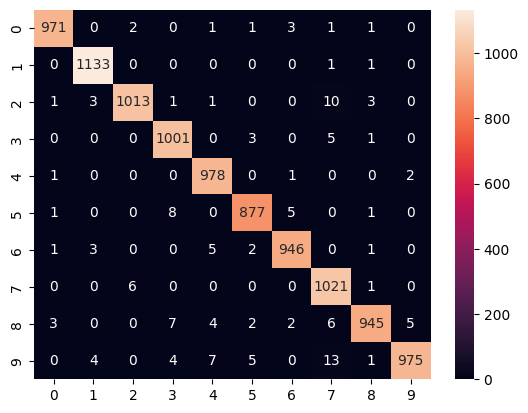

In [93]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred=model.predict(X_test)
y_pred_classes=[np.argmax(element) for element in y_pred]
cm=confusion_matrix(y_test,y_pred_classes)
sns.heatmap(cm,annot=True,fmt='d')